In [15]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import pandas as pd
import numpy as np

def generate_fingerprints(smiles_list, radius=2, fpSize=1024):
    fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)
    results = []
    for smiles in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                fp_bits = fp_gen.GetFingerprintAsNumPy(mol)
                results.append({
                    'smiles': smiles,
                    'fingerprint': fp_bits
                })
        except:
            continue
    
    return pd.DataFrame(results)
try:
    df = pd.read_csv('herg_num_data.csv')
    smiles_list = df['standardized_smiles'].tolist()  
    fingerprint_df = generate_fingerprints(smiles_list)
    if not fingerprint_df.empty:
        print(fingerprint_df) 
        print(f"Всего молекул: {len(fingerprint_df)}")
    else:
        print("Не удалось сгенерировать ни одного фингерпринта")
except Exception as e:
    print(f"Произошла ошибка: {str(e)}")


                                                 smiles  \
0     O=C1NCCN1CCN1CCC(c2cn(-c3ccccc3)c3ccc(Cl)cc23)CC1   
1      O=C1NCCN1CCN1CCC(c2cn(C3CCCCC3)c3ccc(Cl)cc23)CC1   
2                CCC(CC)c1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12   
3     O=C1NCCN1CCN1CC=C(c2cn(-c3ccc(F)cc3)c3ccc(Cl)c...   
4                   CC(C)(C)c1ccc2c(ccn2-c2ccc(F)cc2)c1   
...                                                 ...   
9899  N#Cc1ccc(COc2cccc(N3C=NN(Cc4nc5c(F)cc(C(=O)O)c...   
9900  O=C(O)c1cc(F)c2nc(CN3CCN(c4cccc(OCc5ccc(Cl)c6c...   
9901  O=C(O)c1cc(F)c2nc(CN3CCN(c4cccc(OCc5ccc(Cl)c6c...   
9902  COc1cc2c(cc1-c1c(C)noc1C)ncc1[nH]c(=O)n(C(C)c3...   
9903  CCC(=O)N1CCC(Nc2ncnc3c2CN(c2cnc(OC)c(C(F)(F)F)...   

                                            fingerprint  
0     [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1     [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2     [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4

среднее значение pIC50: 5.192855927449159
среднее отклонение от выборки pIC50: 0.8485098231938889

Распределение классов:
Класс 0 (нетоксичные): 5220 молекул
Класс 1 (токсичные): 4487 молекул
Соотношение: 0.8595785440613026:1
Исходный размер данных: 9904
Точек после фильтрации 3-сигма: 9707
Порог токсичности: 5.0
Классы: 0 (нетоксичные) = 5220, 1 (токсичные) = 4487

Распределение классов в обучающей выборке:
Класс 0: 4296 | Класс 1: 3709
Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Оценка лучшей модели:

Train Metrics:
Confusion Matrix:
[[4191  105]
 [ 174 3535]]
Balanced Accuracy: 0.9643
Precision: 0.9712
Recall (Sensitivity): 0.9531
F1 Score: 0.9620
ROC AUC: 0.9956

Test Metrics:
Confusion Matrix:
[[733 191]
 [226 552]]
Balanced Accuracy: 0.7514
Precision: 0.7429
Recall (Sensitivity): 0.7095
F1 Score: 0.7258
ROC AUC: 0.8344


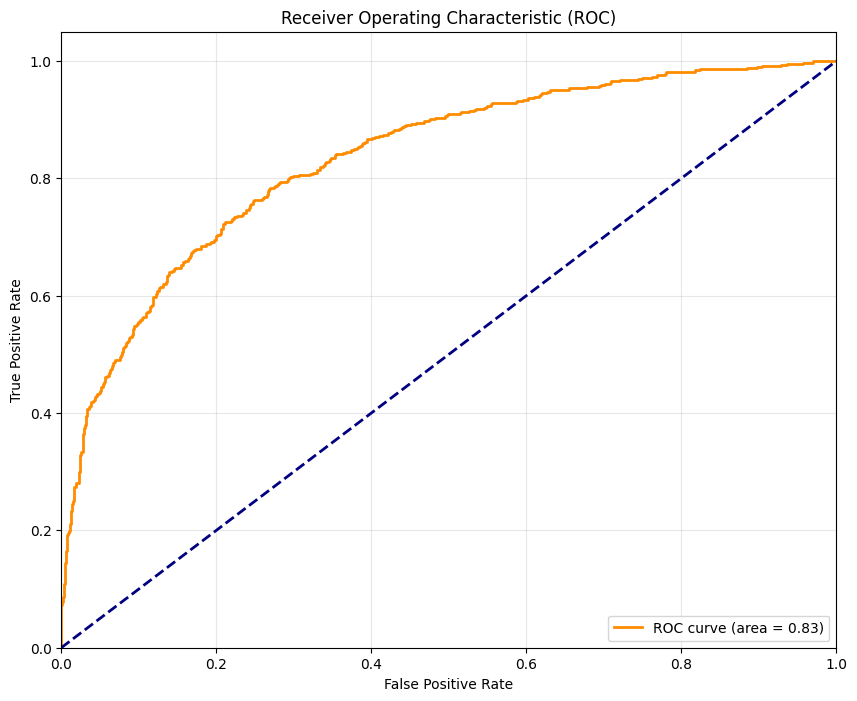


Результаты предсказаний сохранены в classification_predictions.csv
Модель сохранена в файл random_forest_classifier.pkl

Пример предсказаний:
                                              smiles  true_class  \
0                         Nc1nc2ccc(OCc3ccccc3)cc2s1           1   
1  CC(C)C1(C(=O)N2CCN(c3cc(C(F)(F)F)ccn3)CC2)CCC(...           1   
2  O=C(NCCCN1CCCCC1)Nc1ccc(S(=O)(=O)Nc2ccccc2C(=O...           1   
3   N#CC1(CNC(=O)c2cc(Cl)cc(Cl)c2)CCN(CCc2ccccc2)CC1           0   
4  CN(C)c1ccc(C(=O)N(CCCCCC(=O)NO)CC(=O)NCc2ccccc...           1   

   predicted_class  probability_class1  
0                1            0.727314  
1                1            0.664942  
2                1            0.552133  
3                1            0.590206  
4                1            0.694340  


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score
)
import numpy as np
import umap
import hdbscan
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import joblib  

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# 3 сигма, не трогай а то сломается
mean_value = np.mean(df['pIC50']) 
print(f'среднее значение pIC50: {mean_value}') 
std_pIC50 = np.std(df['pIC50']) 
print(f'среднее отклонение от выборки pIC50: {std_pIC50}') 
left = mean_value - 3*std_pIC50
right = mean_value + 3*std_pIC50
mask = (df['pIC50'] > left) & (df['pIC50'] < right)
filtered_df = df[mask]





filtered_indices = fingerprint_df.loc[mask].index.values
fp_array = np.array(fingerprint_df.loc[mask, 'fingerprint'].tolist())
y_continuous = filtered_df.loc[filtered_indices, 'pIC50'].values
threshold = np.median(y_continuous)
y = (y_continuous > threshold).astype(int)

X_train, X_test, y_train, y_test = train_test_split(fp_array, y, test_size=0.15, stratify=y, random_state=42)
# y_continuous = filtered_df.loc[filtered_indices, 'pIC50'].values
# ....threshold = np.median(y_continuous)
# 0 - нетоксичный, 1 - токсичный
# y = (y_continuous > threshold).astype(int) 

class_counts = np.bincount(y)
print(f"\nРаспределение классов:")
print(f"Класс 0 (нетоксичные): {class_counts[0]} молекул")
print(f"Класс 1 (токсичные): {class_counts[1]} молекул")
print(f"Соотношение: {class_counts[1]/class_counts[0]}:1")


print(f"Исходный размер данных: {len(df)}")
print(f"Точек после фильтрации 3-сигма: {len(filtered_df)}")
print(f"Порог токсичности: {threshold}")
print(f"Классы: 0 (нетоксичные) = {class_counts[0]}, 1 (токсичные) = {class_counts[1]}")





cluster_df = pd.DataFrame({
    'smiles': fingerprint_df.loc[mask, 'smiles'],
    'original_index': filtered_indices
})

reducer = umap.UMAP(
    n_components=5, 
    random_state=42,
    n_jobs=1, 
)

the_main_data_array = reducer.fit_transform(fp_array)
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
clusters = clusterer.fit_predict(the_main_data_array)
cluster_df['cluster'] = clusters

train_indices = []
test_indices = []

for cluster_id in np.unique(clusters):
    cluster_data = cluster_df[cluster_df['cluster'] == cluster_id]
    cluster_idx = cluster_data.index
    if len(cluster_idx) > 1:
        clust_train, clust_test = train_test_split(
            cluster_idx, test_size=0.15, random_state=42
        )
        train_indices.extend(cluster_df.loc[clust_train, 'original_index'].values)
        test_indices.extend(cluster_df.loc[clust_test, 'original_index'].values)
    elif len(cluster_idx) == 1:  # Точечные кластеры и шум
        train_indices.extend(cluster_df.loc[cluster_idx, 'original_index'].values)


X_train = fp_array[cluster_df['original_index'].isin(train_indices)]
X_test = fp_array[cluster_df['original_index'].isin(test_indices)]
y_train = y[cluster_df['original_index'].isin(train_indices)]
y_test = y[cluster_df['original_index'].isin(test_indices)]

train_class_counts = np.bincount(y_train)
print(f"\nРаспределение классов в обучающей выборке:")
print(f"Класс 0: {train_class_counts[0]} | Класс 1: {train_class_counts[1]}")

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    error_score='raise'
)

grid_search.fit(X_train, y_train)
print(f"Лучшие параметры: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    for name, X, y_true in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        y_pred = model.predict(X)
        y_proba = model.predict_proba(X)[:, 1]

        cm = confusion_matrix(y_true, y_pred)
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)

        print(f"\n{name} Metrics:")
        print(f"Confusion Matrix:\n{cm}")
        print(f"Balanced Accuracy: {bal_acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall (Sensitivity): {rec:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC AUC: {auc:.4f}")

print("Оценка лучшей модели:")
evaluate_classifier(best_rf, X_train, y_train, X_test, y_test)

from sklearn.metrics import roc_curve, auc

y_proba_test = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=300)
plt.show()

y_pred_test = best_rf.predict(X_test)
# вероятность класса 1(токсичный) 
y_pred_proba_test = best_rf.predict_proba(X_test)[:, 1] 

results_df = pd.DataFrame({
    'original_index': test_indices,
    'true_class': y_test,
    'predicted_class': y_pred_test,
    'probability_class1': y_pred_proba_test
})

results_df = results_df.merge(cluster_df[['original_index', 'smiles']], on='original_index')

results_df.to_csv('classification_predictions.csv', index=False)
print("\nРезультаты предсказаний сохранены в classification_predictions.csv")

model_filename = 'random_forest_classifier.pkl'
joblib.dump(best_rf, model_filename)
print(f"Модель сохранена в файл {model_filename}")

print("\nПример предсказаний:")
print(results_df[['smiles', 'true_class', 'predicted_class', 'probability_class1']].head())